In [9]:
#class weights helps for that
from sklearn.datasets import make_classification

In [10]:
x,y=make_classification(n_samples=1000,n_features=20,n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=[0.99],
    random_state=10)

<Axes: xlabel='0', ylabel='1'>

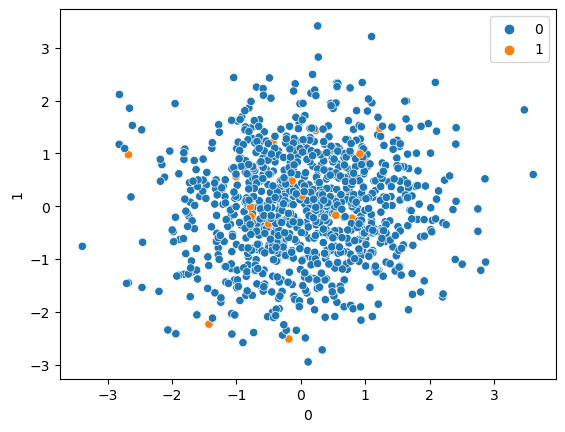

In [11]:
import pandas as pd
import seaborn as sns
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=1)
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [13]:
penalty=["l1","l2","elasticnet"]
c=[100,10,1.0,0.1,0.01]
solver=["sag","saga","liblinear","lbfgs","newton-cg"]
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
params=dict(penalty=penalty,C=c,class_weight=class_weight,solver=solver)


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring="accuracy",cv=5,n_jobs=-1)#njobs uses all the processors in the system